# 02 — WBGT Processing: Daily WBGT → Annual Productivity Loss Rasters

For each year in the configured range, this notebook:
1. Downloads daily WBGT GeoTIFFs **in parallel** to a temporary directory
2. Applies the exposure-response function (WBGT → productivity loss)
3. Deletes each file immediately after reading (minimal disk footprint)
4. Saves one **mean annual productivity loss** raster per year to `data/processed/annual/{dataset}/`

### Datasets
| `DATASET` | Description | Years |
|-----------|-------------|-------|
| `wbgt` | CHIRTS-ERA5 historical WBGT | 1980–2025 |
| `wbgt_baseline` | CHC-CMIP6 observed WBGTmax baseline | 1983–2016 |
| `wbgt_future` | CHC-CMIP6 future WBGTmax (set `FUTURE_EPOCH` + `SCENARIO`) | 1983–2016 |

Set `DATASET`, `FUTURE_EPOCH`, and `SCENARIO` in the **Dataset Selection** cell below, then run all cells.

In [5]:
import sys
import tempfile
from pathlib import Path
from datetime import date, timedelta
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import requests
import rasterio
import yaml
from tqdm.notebook import tqdm

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from scripts.productivity import wbgt_to_productivity_loss

with open(ROOT / 'config' / 'config.yaml') as f:
    config = yaml.safe_load(f)

print('Ready.')

Ready.


## Dataset Selection

Edit the three variables below, then run all cells.

In [6]:
# ------------------------------------------------------------------
# Choose which dataset to process:
#   'wbgt'          — CHIRTS-ERA5 historical
#   'wbgt_baseline' — CHC-CMIP6 observed baseline
#   'wbgt_future'   — CHC-CMIP6 future (set FUTURE_EPOCH + SCENARIO)
# ------------------------------------------------------------------
DATASET      = 'wbgt_future'
FUTURE_EPOCH = '2030'   # '2030' or '2050'  — only used when DATASET='wbgt_future'
SCENARIO     = 'SSP585' # 'ssp245' or 'ssp585' — only used when DATASET='wbgt_future'

# Parallel download workers — keep low (4) to avoid server rate-limiting.
# Increase only if you're on a fast connection and see few/no failures.
N_WORKERS = 4

# Skip years that already have an output raster
SKIP_EXISTING = True

# ------------------------------------------------------------------
# Resolve URL template and output directory from config
# ------------------------------------------------------------------
if DATASET == 'wbgt_future':
    raw = config['wbgt_future']['url_template']
    # Pre-substitute epoch/scenario using replace() to avoid disturbing
    # the {month:02d}/{day:02d} format specs used by the daily loop.
    URL_TEMPLATE = raw.replace('{epoch}', FUTURE_EPOCH).replace('{scenario}', SCENARIO)
    DATASET_LABEL = f'wbgt_future_{FUTURE_EPOCH}_{SCENARIO}'
else:
    URL_TEMPLATE  = config[DATASET]['url_template']
    DATASET_LABEL = DATASET

START_YEAR = config[DATASET if DATASET != 'wbgt_future' else 'wbgt_future']['start_year']
END_YEAR   = config[DATASET if DATASET != 'wbgt_future' else 'wbgt_future']['end_year']

ANNUAL_DIR = ROOT / 'data' / 'processed' / 'annual' / DATASET_LABEL
ANNUAL_DIR.mkdir(parents=True, exist_ok=True)

years_to_process = [
    y for y in range(START_YEAR, END_YEAR + 1)
    if not SKIP_EXISTING or not (ANNUAL_DIR / f'productivity_loss_{y}.tif').exists()
]

print(f'Dataset:        {DATASET_LABEL}')
print(f'Year range:     {START_YEAR}–{END_YEAR}')
print(f'Years to process: {len(years_to_process)}')
print(f'Download workers: {N_WORKERS}')
print(f'Output dir:     {ANNUAL_DIR}')


Dataset:        wbgt_future_2030_SSP585
Year range:     1983–2016
Years to process: 32
Download workers: 4
Output dir:     E:\Projects\Howden\Heatwaves\howden_heat\data\processed\annual\wbgt_future_2030_SSP585


## Process one raster per year

In [ ]:
import time

HEADERS = {
    'User-Agent': (
        'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
        'AppleWebKit/537.36 (KHTML, like Gecko) '
        'Chrome/120.0.0.0 Safari/537.36'
    )
}

# Shared session for connection reuse
SESSION = requests.Session()
SESSION.headers.update(HEADERS)


def iter_dates(year: int):
    d = date(year, 1, 1)
    while d.year == year:
        yield d
        d += timedelta(days=1)


def download_day(url: str, dest: Path, retries: int = 5, backoff: float = 10.0) -> tuple[Path | None, str | None]:
    """Download one file with retries. Returns (dest, None) on success, (None, reason) on failure."""
    last_reason = None
    for attempt in range(retries):
        try:
            r = SESSION.get(url, timeout=180)
            if r.status_code == 200:
                dest.write_bytes(r.content)
                return dest, None
            elif r.status_code == 404:
                return None, 'HTTP 404'  # genuinely missing — no point retrying
            last_reason = f'HTTP {r.status_code}'
        except Exception as e:
            last_reason = type(e).__name__
        if attempt < retries - 1:
            time.sleep(backoff * (2 ** attempt))  # 10s, 20s, 40s, 80s ...
    return None, last_reason


def process_year(year: int, url_template: str, tmp_dir: Path,
                 n_workers: int = 4) -> tuple[np.ndarray, dict] | None:
    """
    1. Download all daily WBGT files for `year` in parallel.
    2. Process each file from disk (apply ERF, accumulate).
    3. Delete each file immediately after reading.
    Returns (mean_annual_loss_array, raster_meta) or None.
    """
    days = list(iter_dates(year))
    tasks = {
        d: (url_template.format(year=d.year, month=d.month, day=d.day),
            tmp_dir / f'WBGT.{d.year}.{d.month:02d}.{d.day:02d}.tif')
        for d in days
    }

    # --- Parallel download ---
    downloaded = {}
    failure_reasons: dict[str, int] = {}
    failed_dates = []

    with ThreadPoolExecutor(max_workers=n_workers) as ex:
        futures = {ex.submit(download_day, url, path): (d, url)
                   for d, (url, path) in tasks.items()}
        for fut in tqdm(as_completed(futures), total=len(futures),
                        desc=f'  {year} download', leave=False):
            d, url = futures[fut]
            path, reason = fut.result()
            if path:
                downloaded[d] = path
            else:
                failed_dates.append(d)
                failure_reasons[reason] = failure_reasons.get(reason, 0) + 1

    if failed_dates:
        reason_str = ', '.join(f'{r}: {n}' for r, n in sorted(failure_reasons.items()))
        print(f'  {year}: {len(failed_dates)}/{len(days)} days failed [{reason_str}]')
        for ex_d in sorted(failed_dates)[:2]:
            ex_url = url_template.format(year=ex_d.year, month=ex_d.month, day=ex_d.day)
            print(f'    e.g. {ex_d}: {ex_url}')

    if not downloaded:
        return None

    # --- Process from disk, delete immediately after reading ---
    accumulator = None
    valid_count  = None
    ref_meta     = None
    nodata_val   = None

    for d in tqdm(sorted(downloaded), desc=f'  {year} process', leave=False):
        fpath = downloaded[d]
        try:
            with rasterio.open(fpath) as src:
                if ref_meta is None:
                    ref_meta   = src.meta.copy()
                    ref_meta.update(dtype='float32', nodata=np.nan)
                    shape      = (src.height, src.width)
                    nodata_val = src.nodata
                    accumulator = np.zeros(shape, dtype=np.float64)
                    valid_count = np.zeros(shape, dtype=np.int32)
                wbgt = src.read(1).astype(np.float32)
        except Exception:
            continue
        finally:
            fpath.unlink(missing_ok=True)

        if nodata_val is not None:
            wbgt[wbgt == nodata_val] = np.nan

        loss  = wbgt_to_productivity_loss(wbgt)
        valid = ~np.isnan(loss)
        accumulator[valid] += loss[valid]
        valid_count[valid] += 1

    if valid_count is None or valid_count.max() == 0:
        return None

    mean_loss = np.where(valid_count > 0, accumulator / valid_count, np.nan).astype(np.float32)
    return mean_loss, ref_meta


# --- Main loop ---
with tempfile.TemporaryDirectory() as tmp:
    tmp_dir = Path(tmp)
    for year in tqdm(years_to_process, desc='Years'):
        out_path = ANNUAL_DIR / f'productivity_loss_{year}.tif'
        result = process_year(year, URL_TEMPLATE, tmp_dir, n_workers=N_WORKERS)
        if result is None:
            print(f'  {year}: no data — skipping')
            continue
        mean_loss, ref_meta = result
        with rasterio.open(out_path, 'w', **ref_meta) as dst:
            dst.write(mean_loss, 1)
        print(f'  {year}: saved → {out_path.name}')

print('Done.')


Years:   0%|          | 0/32 [00:00<?, ?it/s]

  1985 download:   0%|          | 0/365 [00:00<?, ?it/s]

  1985 process:   0%|          | 0/365 [00:00<?, ?it/s]

C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_17928\2422719887.py:119: RuntimeWarning: invalid value encountered in divide
  mean_loss = np.where(valid_count > 0, accumulator / valid_count, np.nan).astype(np.float32)


  1985: saved → productivity_loss_1985.tif


...

  2006: saved → productivity_loss_2006.tif


  2007 download:   0%|          | 0/365 [00:00<?, ?it/s]

  2007 process:   0%|          | 0/365 [00:00<?, ?it/s]

  2007: saved → productivity_loss_2007.tif


  2008 download:   0%|          | 0/366 [00:00<?, ?it/s]

## Check available annual rasters

In [3]:
annual_files = sorted(ANNUAL_DIR.glob('productivity_loss_*.tif'))
years_available = [int(f.stem.split('_')[-1]) for f in annual_files]
print(f'Dataset:  {DATASET_LABEL}')
print(f'Annual rasters available: {len(annual_files)}')
if years_available:
    print(f'Range: {min(years_available)}–{max(years_available)}')

Dataset:  wbgt_future_2030_SSP585
Annual rasters available: 2
Range: 1983–1984


## Quick visual check — single year

Dataset: wbgt_future_2030_SSP585  |  Year: 1984
Loss range: 0.0000 – 0.4138
Mean (valid cells): 0.0327


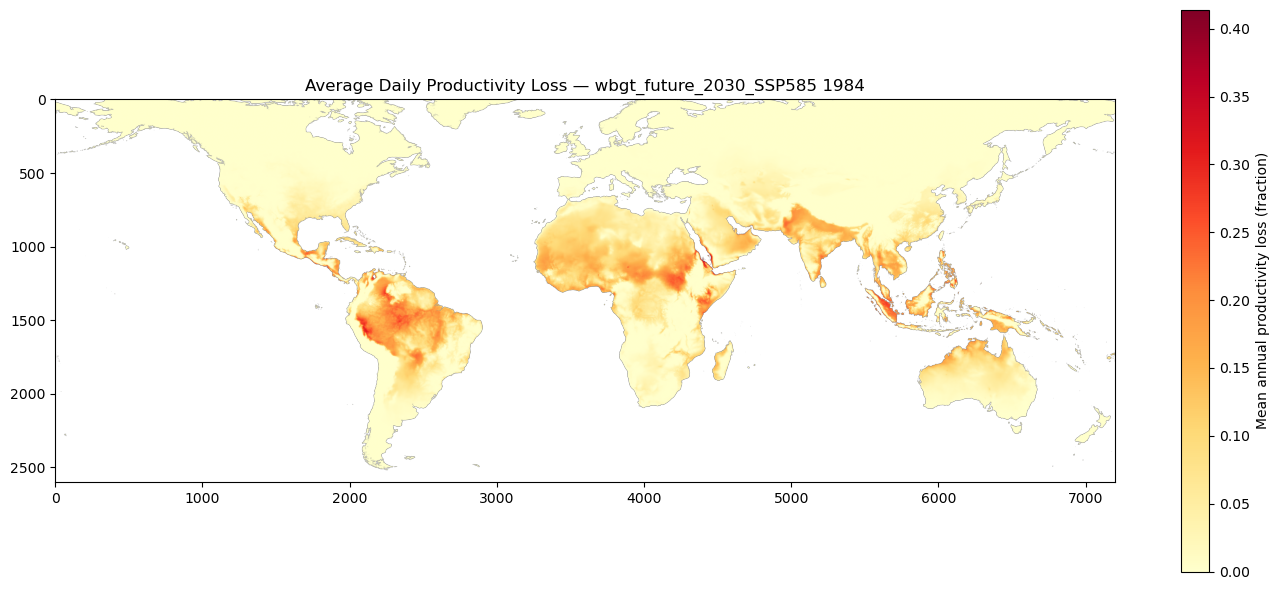

In [4]:
import matplotlib.pyplot as plt

CHECK_YEAR = years_available[-1] if years_available else None

if CHECK_YEAR:
    with rasterio.open(ANNUAL_DIR / f'productivity_loss_{CHECK_YEAR}.tif') as src:
        arr = src.read(1)

    print(f'Dataset: {DATASET_LABEL}  |  Year: {CHECK_YEAR}')
    print(f'Loss range: {np.nanmin(arr):.4f} – {np.nanmax(arr):.4f}')
    print(f'Mean (valid cells): {np.nanmean(arr):.4f}')

    fig, ax = plt.subplots(figsize=(14, 6))
    im = ax.imshow(arr, cmap='YlOrRd', vmin=0, vmax=np.nanmax(arr))
    plt.colorbar(im, ax=ax, label='Mean annual productivity loss (fraction)')
    ax.set_title(f'Average Daily Productivity Loss — {DATASET_LABEL} {CHECK_YEAR}')
    plt.tight_layout()
    plt.show()